# Notebook 04 — Network Priors, Crosstalk, and Entity Masks

Three network matrices encode biological prior knowledge into the ODE:

| Matrix | Shape | Meaning |
|--------|-------|---------|
| `Cg` | N × N | Global PTM crosstalk (from database) |
| `Cl` | N × N | Local sequence-proximity crosstalk |
| `K_site_kin` | N × M | Kinase → phosphosite weight |


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE_DIR = PROJECT_ROOT / "notebooks" / "sample_data"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
from phoscrosstalk.data_loader import (
    load_site_data, load_kinase_site_matrix, load_tf_network,
    build_tf_prot_weights, row_normalize
)

timepoints = list(range(1, 15))
sites, proteins, site_prot_idx, positions, t, Y, A_data, A_proteins = \
    load_site_data(SAMPLE_DIR / "protephospho.csv", timepoints)
N = len(sites)
print(f"sites: {sites}")
print(f"N = {N} phosphosites, K = {len(proteins)} proteins")


sites: ['EGFR_Y1068', 'EGFR_S1173', 'EGFR_T992', 'MET_Y1068', 'MET_S1173', 'MET_T992', 'ERBB2_Y1068', 'ERBB2_S1173', 'ERBB2_T992']
N = 9 phosphosites, K = 3 proteins


## 1 · Cg and Cl — PTM crosstalk matrices

In [3]:
# PTM database files (SQLite) are not included in sample_data.
# We build placeholder zeros to demonstrate the expected structure.

Cg = np.zeros((N, N), dtype=float)  # global crosstalk — zeros = no DB info
Cl = np.zeros((N, N), dtype=float)  # local proximity crosstalk — build from positions

# Build Cl from residue positions (exponential decay with sequence distance)
length_scale = 50.0
for i in range(N):
    for j in range(N):
        if i == j:
            continue
        if site_prot_idx[i] != site_prot_idx[j]:
            continue  # only intra-protein
        if np.isfinite(positions[i]) and np.isfinite(positions[j]):
            d = abs(positions[i] - positions[j])
            Cl[i, j] = np.exp(-d / length_scale)

print("Cg shape:", Cg.shape, "(all zeros — no PTM DB)")
print("Cl shape:", Cl.shape)
print("Cl[non-zero entries]:")
for i, j in np.argwhere(Cl > 0):
    print(f"  Cl[{sites[i]}, {sites[j]}] = {Cl[i,j]:.4f}  (|pos diff| = {abs(positions[i]-positions[j]):.0f})")


Cg shape: (9, 9) (all zeros — no PTM DB)
Cl shape: (9, 9)
Cl[non-zero entries]:
  Cl[EGFR_Y1068, EGFR_S1173] = 0.1225  (|pos diff| = 105)
  Cl[EGFR_Y1068, EGFR_T992] = 0.2187  (|pos diff| = 76)
  Cl[EGFR_S1173, EGFR_Y1068] = 0.1225  (|pos diff| = 105)
  Cl[EGFR_S1173, EGFR_T992] = 0.0268  (|pos diff| = 181)
  Cl[EGFR_T992, EGFR_Y1068] = 0.2187  (|pos diff| = 76)
  Cl[EGFR_T992, EGFR_S1173] = 0.0268  (|pos diff| = 181)
  Cl[MET_Y1068, MET_S1173] = 0.1225  (|pos diff| = 105)
  Cl[MET_Y1068, MET_T992] = 0.2187  (|pos diff| = 76)
  Cl[MET_S1173, MET_Y1068] = 0.1225  (|pos diff| = 105)
  Cl[MET_S1173, MET_T992] = 0.0268  (|pos diff| = 181)
  Cl[MET_T992, MET_Y1068] = 0.2187  (|pos diff| = 76)
  Cl[MET_T992, MET_S1173] = 0.0268  (|pos diff| = 181)
  Cl[ERBB2_Y1068, ERBB2_S1173] = 0.1225  (|pos diff| = 105)
  Cl[ERBB2_Y1068, ERBB2_T992] = 0.2187  (|pos diff| = 76)
  Cl[ERBB2_S1173, ERBB2_Y1068] = 0.1225  (|pos diff| = 105)
  Cl[ERBB2_S1173, ERBB2_T992] = 0.0268  (|pos diff| = 181)
  Cl[ERBB2_

## 2 · K_site_kin — kinase–site weight matrix

In [4]:
K_site_kin, kinases = load_kinase_site_matrix(SAMPLE_DIR / "kinase_sites.tsv", sites)
M = len(kinases)

print(f"K_site_kin shape: {K_site_kin.shape}  (N_sites × N_kinases)")
print(f"kinases: {kinases}")
print()
df_kskin = pd.DataFrame(K_site_kin, index=sites, columns=kinases)
print(df_kskin.round(4))


K_site_kin shape: (9, 2)  (N_sites × N_kinases)
kinases: ['EGFR', 'MET']

               EGFR     MET
EGFR_Y1068   0.1571  0.8429
EGFR_S1173   0.6795  0.3205
EGFR_T992    1.0000  0.0000
MET_Y1068    0.7193  0.2807
MET_S1173    0.1383  0.8617
MET_T992     1.0000  0.0000
ERBB2_Y1068  0.6150  0.3850
ERBB2_S1173  1.0000  0.0000
ERBB2_T992   1.0000  0.0000


## 3 · Row-normalisation

In [5]:
K_site_kin_norm = row_normalize(K_site_kin)
print("After row_normalize — each row sums to ≤1:")
df_norm = pd.DataFrame(K_site_kin_norm, index=sites, columns=kinases)
print(df_norm.round(4))
print("\nRow sums:", K_site_kin_norm.sum(axis=1).round(4))


After row_normalize — each row sums to ≤1:
               EGFR     MET
EGFR_Y1068   0.1571  0.8429
EGFR_S1173   0.6795  0.3205
EGFR_T992    1.0000  0.0000
MET_Y1068    0.7193  0.2807
MET_S1173    0.1383  0.8617
MET_T992     1.0000  0.0000
ERBB2_Y1068  0.6150  0.3850
ERBB2_S1173  1.0000  0.0000
ERBB2_T992   1.0000  0.0000

Row sums: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4 · R matrix — kinase feedback support

In [6]:
# R = K_site_kin.T  →  shape (M, N)
# R[m, n] answers: "how strongly does kinase m support site n?"
R = K_site_kin_norm.T
print(f"R shape: {R.shape}  (M_kinases × N_sites)")
df_R = pd.DataFrame(R, index=kinases, columns=sites)
print(df_R.round(4))


R shape: (2, 9)  (M_kinases × N_sites)
      EGFR_Y1068  EGFR_S1173  EGFR_T992  MET_Y1068  MET_S1173  MET_T992  \
EGFR      0.1571      0.6795        1.0     0.7193     0.1383       1.0   
MET       0.8429      0.3205        0.0     0.2807     0.8617       0.0   

      ERBB2_Y1068  ERBB2_S1173  ERBB2_T992  
EGFR        0.615          1.0         1.0  
MET         0.385          0.0         0.0  


## 5 · L_alpha — kinase network Laplacian

In [7]:
# L_alpha regularises kinase activation via a graph Laplacian.
# If no kinase–kinase graph is available, use a zero matrix (no regularisation).
L_alpha = np.zeros((M, M), dtype=float)
print(f"L_alpha shape: {L_alpha.shape}  (M × M)  — zero = no kinase graph prior")


L_alpha shape: (2, 2)  (M × M)  — zero = no kinase graph prior


## 6 · site_prot_idx — entity mask

site_prot_idx maps each phosphosite to its parent protein:
  site EGFR_Y1068         → protein index 0  (EGFR)
  site EGFR_S1173         → protein index 0  (EGFR)
  site EGFR_T992          → protein index 0  (EGFR)
  site MET_Y1068          → protein index 2  (MET)
  site MET_S1173          → protein index 2  (MET)
  site MET_T992           → protein index 2  (MET)
  site ERBB2_Y1068        → protein index 1  (ERBB2)
  site ERBB2_S1173        → protein index 1  (ERBB2)
  site ERBB2_T992         → protein index 1  (ERBB2)


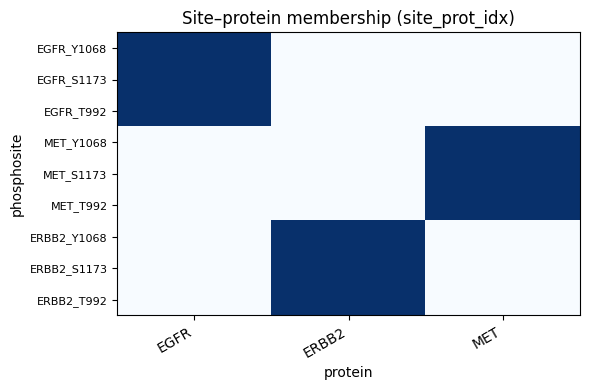

In [8]:
print("site_prot_idx maps each phosphosite to its parent protein:")
for s, k in zip(sites, site_prot_idx):
    print(f"  site {s:<18} → protein index {k}  ({proteins[k]})")

# Visualise as a binary membership matrix
membership = np.zeros((N, len(proteins)), dtype=int)
for n, k in enumerate(site_prot_idx):
    membership[n, k] = 1

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(membership, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(proteins)))
ax.set_xticklabels(proteins, rotation=30, ha="right")
ax.set_yticks(range(N))
ax.set_yticklabels(sites, fontsize=8)
ax.set_title("Site–protein membership (site_prot_idx)")
ax.set_xlabel("protein")
ax.set_ylabel("phosphosite")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_site_protein_membership.png", dpi=100)
plt.show()


## 7 · TF network — tf_prot_weights

In [9]:
tf_df = load_tf_network(SAMPLE_DIR / "tf_mrna.csv", gene_ids=proteins)
print("TF network dataframe:")
print(tf_df)
print()

tf_weights = build_tf_prot_weights(tf_df, gene_ids=proteins, proteins=proteins)
print("tf_prot_weights shape:", tf_weights.shape, "  (K × K)  — TF → protein synthesis weight")
print(pd.DataFrame(tf_weights, index=proteins, columns=proteins).round(4))


TF network dataframe:
  source target    weight
0  ERBB2   EGFR  0.747773
1  ERBB2    MET  0.693236
2    MET    MET  0.926073
3    MET  ERBB2  0.873950

tf_prot_weights shape: (3, 3)   (K × K)  — TF → protein synthesis weight
       EGFR   ERBB2     MET
EGFR    0.0  0.7478  0.0000
ERBB2   0.0  0.0000  0.8739
MET     0.0  0.6932  0.9261


## 8 · Kinase–site biology

In [10]:
print("Kinase–substrate relationships in sample data:")
for s in sites:
    prot, residue = s.split("_", 1)
    row = K_site_kin_norm[sites.index(s)]
    kinase_str = ", ".join(f"{kinases[j]}({row[j]:.2f})" for j in range(M) if row[j] > 0)
    print(f"  {s:<20} phosphorylated by: {kinase_str or 'none'}")


Kinase–substrate relationships in sample data:
  EGFR_Y1068           phosphorylated by: EGFR(0.16), MET(0.84)
  EGFR_S1173           phosphorylated by: EGFR(0.68), MET(0.32)
  EGFR_T992            phosphorylated by: EGFR(1.00)
  MET_Y1068            phosphorylated by: EGFR(0.72), MET(0.28)
  MET_S1173            phosphorylated by: EGFR(0.14), MET(0.86)
  MET_T992             phosphorylated by: EGFR(1.00)
  ERBB2_Y1068          phosphorylated by: EGFR(0.61), MET(0.39)
  ERBB2_S1173          phosphorylated by: EGFR(1.00)
  ERBB2_T992           phosphorylated by: EGFR(1.00)
